<a href="https://colab.research.google.com/github/authcar/Audreys-portofolio/blob/main/DiabetesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

kolom = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv(url, header=None, names=kolom)

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris  : {df.shape[0]}")
print(f"   Jumlah kolom  : {df.shape[1]}")
print(f"\nPreview data (5 baris pertama):")
df.head()


✅ Dataset berhasil dimuat!
   Jumlah baris  : 768
   Jumlah kolom  : 9

Preview data (5 baris pertama):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("=" * 55)
print("  EKSPLORASI DATA")
print("=" * 55)

# Info umum
print("\n📋 Tipe Data & Jumlah Non-Null:")
print(df.info())

# Statistik deskriptif
print("\n📊 Statistik Deskriptif:")
print(df.describe().round(2))

# Distribusi kelas target
print("\n🎯 Distribusi Kelas Target (Outcome):")
counts = df['Outcome'].value_counts()
pct    = df['Outcome'].value_counts(normalize=True) * 100
result = pd.DataFrame({'Jumlah': counts, 'Persentase (%)': pct.round(1)})
result.index = ['Tidak Diabetes (0)', 'Diabetes (1)']
print(result)

  EKSPLORASI DATA

📋 Tipe Data & Jumlah Non-Null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

📊 Statistik Deskriptif:
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean

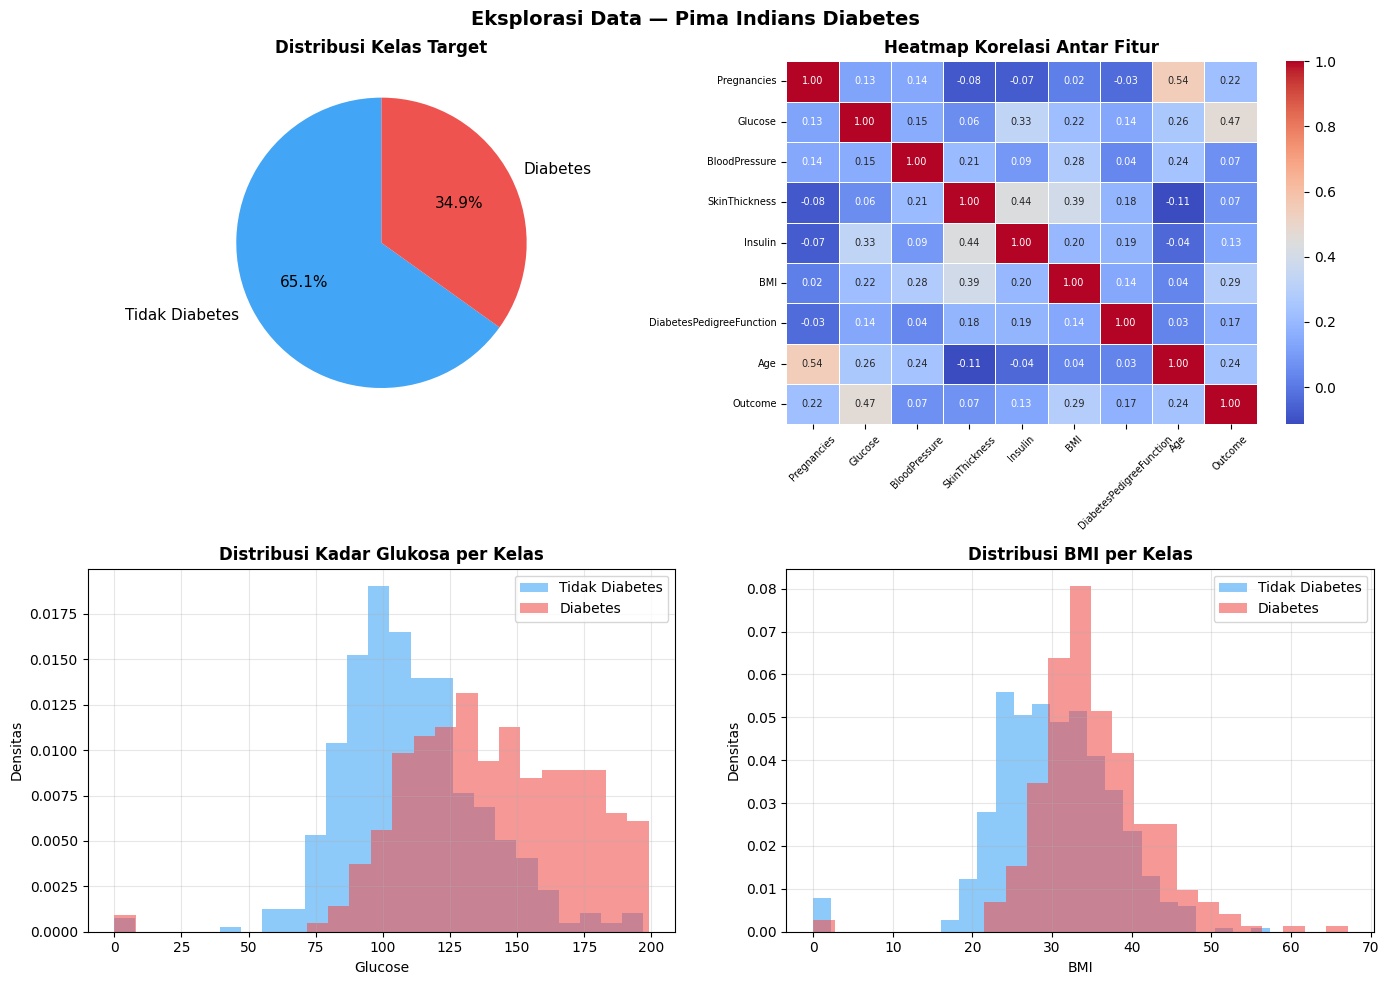

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eksplorasi Data — Pima Indians Diabetes',
             fontsize=14, fontweight='bold')

# Plot 1: Distribusi kelas (pie chart)
ax1 = axes[0, 0]
labels = ['Tidak Diabetes', 'Diabetes']
colors = ['#42A5F5', '#EF5350']
ax1.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribusi Kelas Target', fontweight='bold')

# Plot 2: Heatmap korelasi
ax2 = axes[0, 1]
corr = df.corr()  #menghitung Pearson Correlation
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax2, annot_kws={'size': 7}, linewidths=0.5)
ax2.set_title('Heatmap Korelasi Antar Fitur', fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.tick_params(axis='y', rotation=0,  labelsize=7)

# Plot 3: Distribusi Glucose per kelas
ax3 = axes[1, 0]
for cls, color, label in zip([0,1], ['#42A5F5','#EF5350'],
                              ['Tidak Diabetes','Diabetes']):
    subset = df[df['Outcome'] == cls]['Glucose']
    ax3.hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
ax3.set_title('Distribusi Kadar Glukosa per Kelas', fontweight='bold')
ax3.set_xlabel('Glucose')
ax3.set_ylabel('Densitas')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Distribusi BMI per kelas
ax4 = axes[1, 1]
for cls, color, label in zip([0,1], ['#42A5F5','#EF5350'],
                              ['Tidak Diabetes','Diabetes']):
    subset = df[df['Outcome'] == cls]['BMI']
    ax4.hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
ax4.set_title('Distribusi BMI per Kelas', fontweight='bold')
ax4.set_xlabel('BMI')
ax4.set_ylabel('Densitas')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("  PREPROCESSING")
print("=" * 55)

cols_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Cek SEBELUM dibersihkan
print("\n⚠️  Jumlah nilai 0 (tidak valid) per kolom:")
for col in cols_invalid:
    n_zeros = (df[col] == 0).sum()
    print(f"   {col:30s}: {n_zeros} baris")

# Proses pembersihan
df_clean = df.copy()
for col in cols_invalid:
    median_0 = df[df['Outcome'] == 0][col].median()
    median_1 = df[df['Outcome'] == 1][col].median()
    df_clean.loc[(df_clean['Outcome'] == 0) & (df_clean[col] == 0), col] = median_0
    df_clean.loc[(df_clean['Outcome'] == 1) & (df_clean[col] == 0), col] = median_1

# Cek SESUDAH dibersihkan
print("\n✅ Jumlah nilai 0 SESUDAH dibersihkan:")
for col in cols_invalid:
    n_zeros = (df_clean[col] == 0).sum()
    print(f"   {col:30s}: {n_zeros} baris")

print(f"\n   Missing value tersisa: {df_clean.isnull().sum().sum()}")

# Pisahkan fitur dan target
X = df_clean[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']]
y = df_clean['Outcome']

print(f"\n   Fitur (X) : {X.shape[1]} kolom")
print(f"   Target (y): {y.shape[0]} baris")

  PREPROCESSING

⚠️  Jumlah nilai 0 (tidak valid) per kolom:
   Glucose                       : 5 baris
   BloodPressure                 : 35 baris
   SkinThickness                 : 227 baris
   Insulin                       : 374 baris
   BMI                           : 11 baris

✅ Jumlah nilai 0 SESUDAH dibersihkan:
   Glucose                       : 0 baris
   BloodPressure                 : 0 baris
   SkinThickness                 : 0 baris
   Insulin                       : 138 baris
   BMI                           : 0 baris

   Missing value tersisa: 0

   Fitur (X) : 4 kolom
   Target (y): 768 baris


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Tabel pembagian data
tabel_split = pd.DataFrame({
    'Keterangan': ['Total Data', 'Data Train (80%)', 'Data Test (20%)'],
    'Jumlah'    : [len(X), len(X_train), len(X_test)],
    'Kelas 0 (Tidak Diabetes)': [
        (y == 0).sum(),
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ],
    'Kelas 1 (Diabetes)': [
        (y == 1).sum(),
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ]
})
print(tabel_split.to_string(index=False))

print("=" * 55)
print("  SPLIT DATA")
print("=" * 55)
print(f"\n   Total data  : {len(X)}")
print(f"   Data Train  : {len(X_train)} baris ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Data Test   : {len(X_test)} baris ({len(X_test)/len(X)*100:.0f}%)")

print(f"\n   Distribusi kelas — Train:")
print(f"   {y_train.value_counts().to_dict()}")
print(f"\n   Distribusi kelas — Test:")
print(f"   {y_test.value_counts().to_dict()}")

      Keterangan  Jumlah  Kelas 0 (Tidak Diabetes)  Kelas 1 (Diabetes)
      Total Data     768                       500                 268
Data Train (80%)     614                       400                 214
 Data Test (20%)     154                       100                  54
  SPLIT DATA

   Total data  : 768
   Data Train  : 614 baris (80%)
   Data Test   : 154 baris (20%)

   Distribusi kelas — Train:
   {0: 400, 1: 214}

   Distribusi kelas — Test:
   {0: 100, 1: 54}


In [ ]:
# SMOTE
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

print("=" * 55)
print("  SMOTE — MENGATASI DATA TIDAK SEIMBANG")
print("=" * 55)

print("\n⚠️  Distribusi SEBELUM SMOTE (data train):")
print(y_train.value_counts().rename({0:'Tidak Diabetes', 1:'Diabetes'}).to_string())

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("\n✅ Distribusi SESUDAH SMOTE (data train):")
print(y_train_sm.value_counts().rename({0:'Tidak Diabetes', 1:'Diabetes'}).to_string())
print(f"\n   Data train bertambah dari {len(X_train)} → {len(X_train_sm)} baris")

  SMOTE — MENGATASI DATA TIDAK SEIMBANG

⚠️  Distribusi SEBELUM SMOTE (data train):
Outcome
Tidak Diabetes    400
Diabetes          214

✅ Distribusi SESUDAH SMOTE (data train):
Outcome
Tidak Diabetes    400
Diabetes          400

   Data train bertambah dari 614 → 800 baris


In [ ]:
model = GaussianNB()
model.fit(X_train_sm, y_train_sm)

print("=" * 55)
print("  TRAINING MODEL — GAUSSIAN NAIVE BAYES")
print("=" * 55)
print("\n✅ Model selesai dilatih!")

print("\n📌 Prior Probability (dari data training):")
for cls, prior in zip(model.classes_, model.class_prior_):
    label = "Tidak Diabetes" if cls == 0 else "Diabetes"
    print(f"   P(Kelas {cls} — {label}) = {prior:.4f}")

print("\n📌 Mean tiap fitur per kelas (θ):")
mean_df = pd.DataFrame(
    model.theta_,
    columns=X.columns,
    index=['Kelas 0 (Tidak Diabetes)', 'Kelas 1 (Diabetes)']
)
print(mean_df.round(2))

  TRAINING MODEL — GAUSSIAN NAIVE BAYES

✅ Model selesai dilatih!

📌 Prior Probability (dari data training):
   P(Kelas 0 — Tidak Diabetes) = 0.5000
   P(Kelas 1 — Diabetes) = 0.5000

📌 Mean tiap fitur per kelas (θ):
                          Glucose    BMI    Age  DiabetesPedigreeFunction
Kelas 0 (Tidak Diabetes)   110.39  30.77  31.28                      0.44
Kelas 1 (Diabetes)         141.46  35.85  36.25                      0.54


In [ ]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
accuracy    = accuracy_score(y_test, y_pred)

print("=" * 55)
print("  EVALUASI MODEL")
print("=" * 55)
print(f"\n🎯 Akurasi          : {accuracy * 100:.2f}%")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)
print(f"📈 ROC-AUC Score    : {roc_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Tidak Diabetes', 'Diabetes']))


  EVALUASI MODEL

🎯 Akurasi          : 72.73%
📈 ROC-AUC Score    : 0.7935

📋 Classification Report:
                precision    recall  f1-score   support

Tidak Diabetes       0.82      0.75      0.78       100
      Diabetes       0.60      0.69      0.64        54

      accuracy                           0.73       154
     macro avg       0.71      0.72      0.71       154
  weighted avg       0.74      0.73      0.73       154



In [ ]:
#  Perbandingan Sebelum vs Sesudah SMOTE
from sklearn.metrics import f1_score, precision_score, recall_score

model_tanpa = GaussianNB()
model_tanpa.fit(X_train, y_train)
y_pred_tanpa = model_tanpa.predict(X_test)
y_pred_smote = model.predict(X_test)

hasil = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision (Diabetes)', 'Recall (Diabetes)', 'F1-Score (Diabetes)'],
    'Tanpa SMOTE': [
        f"{accuracy_score(y_test, y_pred_tanpa)*100:.2f}%",
        f"{precision_score(y_test, y_pred_tanpa)*100:.2f}%",
        f"{recall_score(y_test, y_pred_tanpa)*100:.2f}%",
        f"{f1_score(y_test, y_pred_tanpa)*100:.2f}%"
    ],
    'Dengan SMOTE': [
        f"{accuracy_score(y_test, y_pred_smote)*100:.2f}%",
        f"{precision_score(y_test, y_pred_smote)*100:.2f}%",
        f"{recall_score(y_test, y_pred_smote)*100:.2f}%",
        f"{f1_score(y_test, y_pred_smote)*100:.2f}%"
    ]
})

print("=" * 55)
print("  PERBANDINGAN HASIL — SEBELUM vs SESUDAH SMOTE")
print("=" * 55)
print(hasil.to_string(index=False))
print("\n💡 Recall (Diabetes) = metrik terpenting di bidang medis dari tabel, artinya lebih banyak pasien diabetes yang berhasil terdeteksi.")

  PERBANDINGAN HASIL — SEBELUM vs SESUDAH SMOTE
              Metrik Tanpa SMOTE Dengan SMOTE
            Accuracy      72.08%       72.73%
Precision (Diabetes)      61.70%       59.68%
   Recall (Diabetes)      53.70%       68.52%
 F1-Score (Diabetes)      57.43%       63.79%

💡 Recall (Diabetes) = metrik terpenting di bidang medis


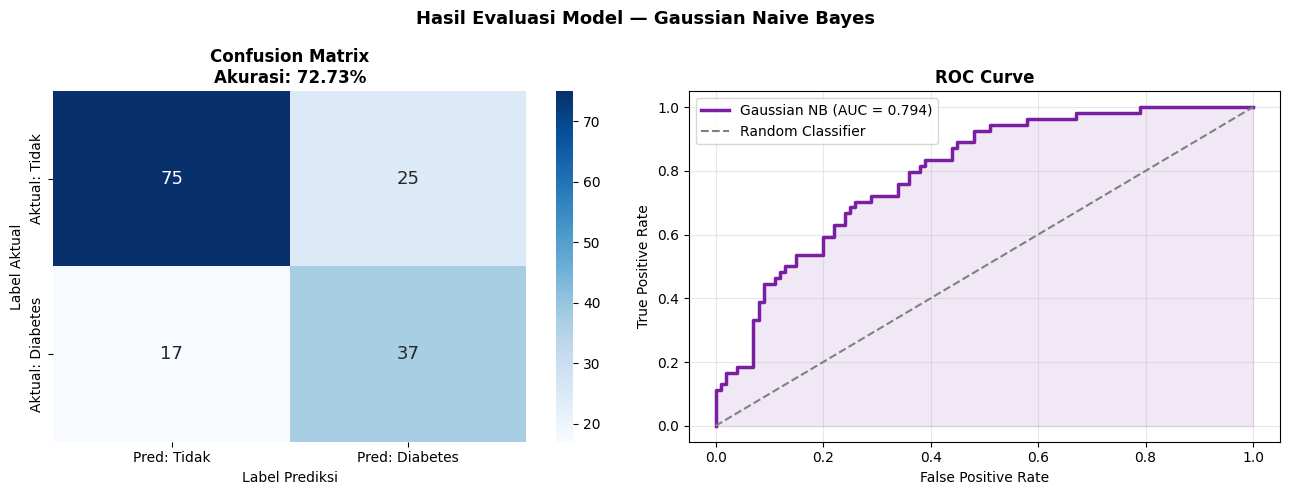

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hasil Evaluasi Model — Gaussian Naive Bayes',
             fontsize=13, fontweight='bold')

# Confusion Matrix
ax1 = axes[0]
cm  = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred: Tidak', 'Pred: Diabetes'],
            yticklabels=['Aktual: Tidak', 'Aktual: Diabetes'],
            annot_kws={'size': 13})
ax1.set_title(f'Confusion Matrix\nAkurasi: {accuracy*100:.2f}%',
              fontweight='bold')
ax1.set_ylabel('Label Aktual')
ax1.set_xlabel('Label Prediksi')

# ROC Curve
ax2 = axes[1]
ax2.plot(fpr, tpr, color='#7B1FA2', lw=2.5,
         label=f'Gaussian NB (AUC = {roc_auc:.3f})')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#7B1FA2')
ax2.plot([0,1],[0,1], color='gray', linestyle='--', lw=1.5,
         label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 10 — Prediksi Pasien Baru (4 fitur)
print("=" * 55)
print("  PREDIKSI PASIEN BARU")
print("=" * 55)

# Format: [Glucose, BMI, Age, DiabetesPedigreeFunction]
pasien_baru = pd.DataFrame({
    'Glucose'                 : [85,  183],
    'BMI'                     : [26.6, 23.3],
    'Age'                     : [31,  32],
    'DiabetesPedigreeFunction': [0.351, 0.672]
})

prediksi     = model.predict(pasien_baru)
probabilitas = model.predict_proba(pasien_baru)

for i in range(len(pasien_baru)):
    label = "⚠️  DIABETES" if prediksi[i] == 1 else "✅ TIDAK DIABETES"
    print(f"\n  Pasien {i+1}:")
    print(f"  Glucose : {pasien_baru.iloc[i]['Glucose']}")
    print(f"  BMI     : {pasien_baru.iloc[i]['BMI']}")
    print(f"  Age     : {pasien_baru.iloc[i]['Age']}")
    print(f"  DPF     : {pasien_baru.iloc[i]['DiabetesPedigreeFunction']}")
    print(f"  Hasil   : {label}")
    print(f"  Prob    : Tidak Diabetes={probabilitas[i][0]:.3f} | Diabetes={probabilitas[i][1]:.3f}")

  PREDIKSI PASIEN BARU

  Pasien 1:
  Glucose : 85.0
  BMI     : 26.6
  Age     : 31.0
  DPF     : 0.351
  Hasil   : ✅ TIDAK DIABETES
  Prob    : Tidak Diabetes=0.933 | Diabetes=0.067

  Pasien 2:
  Glucose : 183.0
  BMI     : 23.3
  Age     : 32.0
  DPF     : 0.672
  Hasil   : ⚠️  DIABETES
  Prob    : Tidak Diabetes=0.078 | Diabetes=0.922
